# XGBoost — Wind Speed Forecasting
## Variable Set 1

In [3]:
# =============================================================================
# INSTALLING PACKAGES
# =============================================================================
# !pip install statsmodels optuna tabulate gdown xgboost

In [4]:
# =============================================================================
# IMPORTS
# =============================================================================
!pip install optuna
# Standard libraries
import os
import sys
import random
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from matplotlib.colors import ListedColormap

# Scikit-learn: preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn import model_selection, metrics, preprocessing

# Scikit-learn: model selection
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    TimeSeriesSplit
)

# Scikit-learn: metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# XGBoost
import xgboost as xgb
from xgboost import XGBRegressor

# Statistical analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import pointbiserialr, chi2_contingency, spearmanr, entropy
from statsmodels.graphics.gofplots import qqplot

# Tabulate
from tabulate import tabulate

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Suppress Optuna trial logs

# Google Drive download
import gdown

# Global random seed
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Set visualization style
#sns.set()  # Set Seaborn default style
#plt.style.use('ggplot')  # Set ggplot style for matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.6 MB/s eta 0:00:00


In [5]:
# =============================================================================
# LOADING THE DATA SET
# =============================================================================
# Dataset source:
# https://drive.google.com/file/d/1Z_KsoIumw-fvivVombIoWuRo0LOe2nCb/view?usp=sharing
# https://drive.google.com/file/d/1aD1PXfwEEZ_F2lQgxuPfj-TVbxQ6NajK/view?usp=sharing

file_id     = "1qhCB1Dod6jeEsuKy5sNk4MNHSjtENSrx"
download_url = f"https://drive.google.com/uc?id={file_id}"

# Read the data
df = pd.read_csv(download_url)

# Backup original DataFrame
df_backup = df.copy()

In [6]:
# =============================================================================
# DATA PREPROCESSING
# =============================================================================

# Create datetime directly from differently named columns
df['Date'] = pd.to_datetime({
    'year': df['YEAR'],
    'month': df['MO'],
    'day': df['DY']
})

# Set Date as the index
df = df.set_index('Date')

# Drop unnecessary columns
df = df.drop(columns=["YEAR", "MO", "DY"])

# Display the DataFrame (optional in scripts)
print(df.head())
print("\nColumns:", df.columns.tolist())

            WS10M_lag1   PREC     RH  MIN_TEMP  MAX_TEMP    WD_sin  \
Date                                                                 
2013-01-03        4.25  13.42  86.26     23.42     28.38  0.439939   
2013-01-04        4.75   8.79  86.31     22.93     27.58  0.424199   
2013-01-05        5.74   2.60  86.88     22.17     26.16  0.563526   
2013-01-06        5.79   1.65  88.09     23.47     27.75  0.460200   
2013-01-07        4.52  27.41  93.04     24.04     26.70  0.368125   

            SURF_PRESSSURE    WD_cos  AVG_TEMP  WS10M_lag2  PREC_lag1  \
Date                                                                    
2013-01-03           99.68  0.898028      26.4        3.99       1.09   
2013-01-04           99.65  0.905569      25.1        4.25      13.42   
2013-01-05           99.50  0.826098      26.9        4.75       8.79   
2013-01-06           99.47  0.887815      27.3        5.74       2.60   
2013-01-07           99.46  0.929776      25.9        5.79       1.65  

In [7]:
# =============================================================================
# TRAIN / TEST SPLIT  (80% train — 20% test, temporal order preserved)
# =============================================================================
## Data Sets

# Define features and target
X = df.drop(columns=['WS10M'])   # Features (lagged variables)
y = df['WS10M']                  # Target variable (wind speed)

numerical_cols = df.columns

# Define the split index — 80% for training, 20% for testing
split_index = int(len(X) * 0.8)

# Training set
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Testing set
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("X_train:\n", X_train.head())
print("y_train:\n", y_train.head())
print("X_test:\n",  X_test.head())
print("y_test:\n",  y_test.head())

print("\nShapes:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train:
             WS10M_lag1   PREC     RH  MIN_TEMP  MAX_TEMP    WD_sin  \
Date                                                                 
2013-01-03        4.25  13.42  86.26     23.42     28.38  0.439939   
2013-01-04        4.75   8.79  86.31     22.93     27.58  0.424199   
2013-01-05        5.74   2.60  86.88     22.17     26.16  0.563526   
2013-01-06        5.79   1.65  88.09     23.47     27.75  0.460200   
2013-01-07        4.52  27.41  93.04     24.04     26.70  0.368125   

            SURF_PRESSSURE    WD_cos  AVG_TEMP  WS10M_lag2  PREC_lag1  \
Date                                                                    
2013-01-03           99.68  0.898028      26.4        3.99       1.09   
2013-01-04           99.65  0.905569      25.1        4.25      13.42   
2013-01-05           99.50  0.826098      26.9        4.75       8.79   
2013-01-06           99.47  0.887815      27.3        5.74       2.60   
2013-01-07           99.46  0.929776      25.9        5.79   

## Section 1 — Original XGBoost Model (No Hyperparameter Optimisation)
TimeSeriesSplit cross-validation applied on training data only.

In [8]:
# =============================================================================
# SECTION 1 — ORIGINAL MODEL  (No Hyperparameter Optimisation)
# TimeSeriesSplit cross-validation applied on training data only
# =============================================================================
### Original

# Initialize the model (XGBoost Regressor) with fixed random seed
xgb_orig = XGBRegressor(n_estimators=100, random_state=RANDOM_SEED)

# Initialize TimeSeriesSplit — applied on training data only
tscv = TimeSeriesSplit(n_splits=5)

# Lists to store evaluation metrics for each fold
train_mse_list,  test_mse_list  = [], []
train_mae_list,  test_mae_list  = [], []
train_rmse_list, test_rmse_list = [], []
train_mape_list, test_mape_list = [], []
train_r2_list,   test_r2_list   = [], []

# Time series cross-validation loop on training data
# NOTE: X_fold_train / X_fold_val are CV fold splits of X_train only.
#       They do NOT overwrite the original 80/20 X_train / X_test splits.
for fold_train_idx, fold_val_idx in tscv.split(X_train):
    # Split training data into fold train and fold validation sets
    X_fold_train = X_train.iloc[fold_train_idx]
    X_fold_val   = X_train.iloc[fold_val_idx]
    y_fold_train = y_train.iloc[fold_train_idx]
    y_fold_val   = y_train.iloc[fold_val_idx]

    # Train the model on the fold training data
    xgb_orig.fit(X_fold_train, y_fold_train)

    # Predict
    y_fold_train_pred = xgb_orig.predict(X_fold_train)
    y_fold_val_pred   = xgb_orig.predict(X_fold_val)

    # Calculate metrics
    fold_train_mse  = mean_squared_error(y_fold_train, y_fold_train_pred)
    fold_val_mse    = mean_squared_error(y_fold_val,   y_fold_val_pred)
    fold_train_mae  = mean_absolute_error(y_fold_train, y_fold_train_pred)
    fold_val_mae    = mean_absolute_error(y_fold_val,   y_fold_val_pred)
    fold_train_rmse = np.sqrt(fold_train_mse)
    fold_val_rmse   = np.sqrt(fold_val_mse)
    # Avoid division by zero in MAPE
    fold_train_mape = np.mean(np.abs((y_fold_train - y_fold_train_pred) / np.maximum(y_fold_train, 1e-8))) * 100
    fold_val_mape   = np.mean(np.abs((y_fold_val   - y_fold_val_pred)   / np.maximum(y_fold_val,   1e-8))) * 100
    fold_train_r2   = r2_score(y_fold_train, y_fold_train_pred)    # Added
    fold_val_r2     = r2_score(y_fold_val,   y_fold_val_pred)      # Added

    # Append
    train_mse_list.append(fold_train_mse);   test_mse_list.append(fold_val_mse)
    train_mae_list.append(fold_train_mae);   test_mae_list.append(fold_val_mae)
    train_rmse_list.append(fold_train_rmse); test_rmse_list.append(fold_val_rmse)
    train_mape_list.append(fold_train_mape); test_mape_list.append(fold_val_mape)
    train_r2_list.append(fold_train_r2);     test_r2_list.append(fold_val_r2)   # Added

# Average metrics across CV folds
print(f"Average Train MSE:  {np.mean(train_mse_list):.4f},  Average Val MSE:  {np.mean(test_mse_list):.4f}")
print(f"Average Train MAE:  {np.mean(train_mae_list):.4f},  Average Val MAE:  {np.mean(test_mae_list):.4f}")
print(f"Average Train RMSE: {np.mean(train_rmse_list):.4f}, Average Val RMSE: {np.mean(test_rmse_list):.4f}")
print(f"Average Train MAPE: {np.mean(train_mape_list):.4f}%, Average Val MAPE: {np.mean(test_mape_list):.4f}%")
print(f"Average Train R²:   {np.mean(train_r2_list):.4f},  Average Val R²:   {np.mean(test_r2_list):.4f}")  # Added

# --- Optimal performance: refit on full X_train, evaluate on held-out X_test ---
xgb_orig_final = XGBRegressor(n_estimators=100, random_state=RANDOM_SEED)
xgb_orig_final.fit(X_train, y_train)

y_train_pred_orig = xgb_orig_final.predict(X_train)
y_test_pred_orig  = xgb_orig_final.predict(X_test)

# Assign values to new variables
original_train_mse  = mean_squared_error(y_train,  y_train_pred_orig)
original_test_mse   = mean_squared_error(y_test,   y_test_pred_orig)
original_train_mae  = mean_absolute_error(y_train, y_train_pred_orig)
original_test_mae   = mean_absolute_error(y_test,  y_test_pred_orig)
original_train_rmse = np.sqrt(original_train_mse)
original_test_rmse  = np.sqrt(original_test_mse)
# Avoid division by zero in MAPE
original_train_mape = np.mean(np.abs((y_train - y_train_pred_orig) / np.maximum(y_train, 1e-8))) * 100
original_test_mape  = np.mean(np.abs((y_test  - y_test_pred_orig)  / np.maximum(y_test,  1e-8))) * 100
original_train_r2   = r2_score(y_train, y_train_pred_orig)
original_test_r2    = r2_score(y_test,  y_test_pred_orig)

# Print results
print(f"\n📊 Original Model — Optimal Performance (full train → held-out test):")
print(f"Train MSE:  {original_train_mse:.4f},  Test MSE:  {original_test_mse:.4f}")
print(f"Train MAE:  {original_train_mae:.4f},  Test MAE:  {original_test_mae:.4f}")
print(f"Train RMSE: {original_train_rmse:.4f}, Test RMSE: {original_test_rmse:.4f}")
print(f"Train MAPE: {original_train_mape:.4f}%, Test MAPE: {original_test_mape:.4f}%")
print(f"Train R²:   {original_train_r2:.4f},  Test R²:   {original_test_r2:.4f}")

Average Train MSE:  0.0069,  Average Val MSE:  0.6037
Average Train MAE:  0.0494,  Average Val MAE:  0.5954
Average Train RMSE: 0.0690, Average Val RMSE: 0.7768
Average Train MAPE: 1.3961%, Average Val MAPE: 16.8114%
Average Train R²:   0.9972,  Average Val R²:   0.7532

📊 Original Model — Optimal Performance (full train → held-out test):
Train MSE:  0.0283,  Test MSE:  0.5847
Train MAE:  0.1225,  Test MAE:  0.5835
Train RMSE: 0.1682, Test RMSE: 0.7647
Train MAPE: 3.4218%, Test MAPE: 15.9927%
Train R²:   0.9888,  Test R²:   0.7575


In [9]:
# Convert y_train and y_test to DataFrame for plotting
y_train_df = pd.DataFrame({"Train Actual": y_train, "Train Predicted": y_train_pred_orig}, index=X_train.index)
y_test_df  = pd.DataFrame({"Test Actual":  y_test,  "Test Predicted":  y_test_pred_orig},  index=X_test.index)

# Concatenate train and test sets for a single time series view
df_combined = pd.concat([y_train_df, y_test_df], axis=0)

# Create the interactive plot
fig = go.Figure()

# Plot training actual values
fig.add_trace(go.Scatter(x=y_train.index, y=y_train,           mode='lines', name='Train Actual',    line=dict(color='blue')))
# Plot training predicted values
fig.add_trace(go.Scatter(x=y_train.index, y=y_train_pred_orig, mode='lines', name='Train Predicted', line=dict(color='cyan', dash='dot')))
# Plot test actual values
fig.add_trace(go.Scatter(x=y_test.index,  y=y_test,            mode='lines', name='Test Actual',     line=dict(color='red')))
# Plot test predicted values
fig.add_trace(go.Scatter(x=y_test.index,  y=y_test_pred_orig,  mode='lines', name='Test Predicted',  line=dict(color='green', dash='dot')))

# Customize layout
fig.update_layout(
    title="Original XGBoost — Actual vs Predicted (Time Series)",
    xaxis_title="Time",
    yaxis_title="Wind Speed",
    hovermode="x",
    template="plotly_white",
    legend=dict(x=0, y=1)
)
fig.show()

## Section 2 — Grid Search CV Hyperparameter Tuning
TimeSeriesSplit cross-validation applied on training data only.

In [10]:
# =============================================================================
# SECTION 2 — GRID SEARCH CV  Hyperparameter Tuning
# TimeSeriesSplit cross-validation applied on training data only
# =============================================================================
### Grid Search CV Hyper Parameter Tuning

# Define the XGBoost Regressor model with fixed random seed
xgb_grid = XGBRegressor(random_state=RANDOM_SEED)

# Define the parameter grid with reduced parameters for hyperparameter tuning
param_grid = {
    'n_estimators':      [50, 150, 300],
    'max_depth':         [3, 8, 12],
    'gamma':             [0, 0.05, 0.3],
    'subsample':         [0.6, 0.8, 1.0],
    'learning_rate':     [0.01, 0.05, 0.3],
    'min_child_weight':  [1, 3, 5]          # Step size shrinking to prevent overfitting
}

# Initialize TimeSeriesSplit with 5 splits — applied on training data only
tscv = TimeSeriesSplit(n_splits=5)

# Set up GridSearchCV with TimeSeriesSplit — fitted on X_train only (no test set exposure)
grid_search = GridSearchCV(
    estimator=xgb_grid,
    param_grid=param_grid,
    cv=tscv,
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_squared_error',
    refit=True    # Refit best model on full X_train automatically
)

# Fit the model with GridSearchCV on training data only
grid_search.fit(X_train, y_train)

# Get the best parameters from the grid search
grid_best_params = grid_search.best_params_
print(f"Best Parameters: {grid_best_params}")

# Get the best estimator (XGBoost model with optimal parameters)
grid_best_xgb = grid_search.best_estimator_

# --- Optimal performance: predict on full X_train and X_test ---
y_train_pred_grid = grid_best_xgb.predict(X_train)
y_test_pred_grid  = grid_best_xgb.predict(X_test)

# Evaluate the model performance
grid_train_mse  = mean_squared_error(y_train,  y_train_pred_grid)
grid_test_mse   = mean_squared_error(y_test,   y_test_pred_grid)
grid_train_mae  = mean_absolute_error(y_train, y_train_pred_grid)
grid_test_mae   = mean_absolute_error(y_test,  y_test_pred_grid)
grid_train_rmse = np.sqrt(grid_train_mse)
grid_test_rmse  = np.sqrt(grid_test_mse)
# Avoid division by zero in MAPE
grid_train_mape = np.mean(np.abs((y_train - y_train_pred_grid) / np.maximum(y_train, 1e-8))) * 100
grid_test_mape  = np.mean(np.abs((y_test  - y_test_pred_grid)  / np.maximum(y_test,  1e-8))) * 100
# R-squared
grid_train_r2   = r2_score(y_train, y_train_pred_grid)
grid_test_r2    = r2_score(y_test,  y_test_pred_grid)

# Print the evaluation metrics
print(f"\n📊 Grid Search — Optimal Performance:")
print(f"Grid Train MSE:  {grid_train_mse:.4f},  Grid Test MSE:  {grid_test_mse:.4f}")
print(f"Grid Train MAE:  {grid_train_mae:.4f},  Grid Test MAE:  {grid_test_mae:.4f}")
print(f"Grid Train RMSE: {grid_train_rmse:.4f}, Grid Test RMSE: {grid_test_rmse:.4f}")
print(f"Grid Train MAPE: {grid_train_mape:.4f}%, Grid Test MAPE: {grid_test_mape:.4f}%")
print(f"Grid Train R²:   {grid_train_r2:.4f},  Grid Test R²:   {grid_test_r2:.4f}")

# Get the best parameters from the grid search
grid_best_params = grid_search.best_params_
print(f"\nBest Parameters: {grid_best_params}")

# Store evaluation metrics in a dictionary
grid_search_metrics = {
    "grid_train_mse":  grid_train_mse,  "grid_test_mse":  grid_test_mse,
    "grid_train_mae":  grid_train_mae,  "grid_test_mae":  grid_test_mae,
    "grid_train_rmse": grid_train_rmse, "grid_test_rmse": grid_test_rmse,
    "grid_train_mape": grid_train_mape, "grid_test_mape": grid_test_mape
}

# Print stored values
for metric, value in grid_search_metrics.items():
    print(f"{metric}: {value:.4f}")

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Best Parameters: {'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.6}

📊 Grid Search — Optimal Performance:
Grid Train MSE:  0.3361,  Grid Test MSE:  0.5612
Grid Train MAE:  0.4536,  Grid Test MAE:  0.5723
Grid Train RMSE: 0.5797, Grid Test RMSE: 0.7491
Grid Train MAPE: 12.6678%, Grid Test MAPE: 15.5685%
Grid Train R²:   0.8666,  Grid Test R²:   0.7673

Best Parameters: {'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.6}
grid_train_mse: 0.3361
grid_test_mse: 0.5612
grid_train_mae: 0.4536
grid_test_mae: 0.5723
grid_train_rmse: 0.5797
grid_test_rmse: 0.7491
grid_train_mape: 12.6678
grid_test_mape: 15.5685


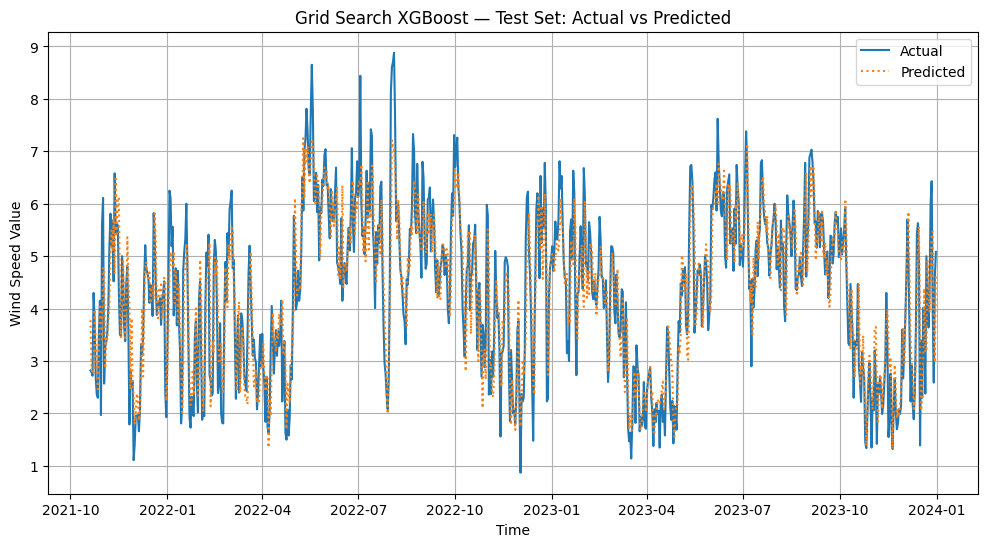

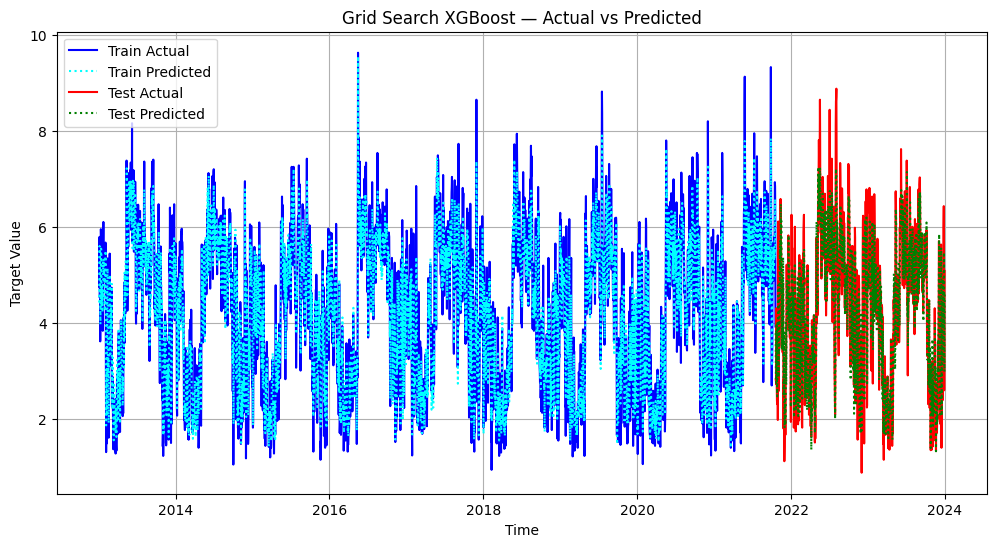

In [11]:
# Create the interactive plot
fig = go.Figure()

# Plot training actual values
fig.add_trace(go.Scatter(x=y_train.index, y=y_train,            mode='lines', name='Train Actual',    line=dict(color='blue')))
# Plot training predicted values
fig.add_trace(go.Scatter(x=y_train.index, y=y_train_pred_grid,  mode='lines', name='Train Predicted', line=dict(color='cyan',  dash='dot')))
# Plot test actual values
fig.add_trace(go.Scatter(x=y_test.index,  y=y_test,             mode='lines', name='Test Actual',     line=dict(color='red')))
# Plot test predicted values
fig.add_trace(go.Scatter(x=y_test.index,  y=y_test_pred_grid,   mode='lines', name='Test Predicted',  line=dict(color='green', dash='dot')))

# Customize layout
fig.update_layout(
    title="Grid Search XGBoost — Actual vs Predicted",
    xaxis_title="Time",
    yaxis_title="Target Value",
    template="plotly_white",
    hovermode="x",
    legend=dict(x=0, y=1)
)
fig.show()

import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 6))

# Plot test actual values
plt.plot(y_test.index, y_test,           label='Actual')
# Plot test predicted values
plt.plot(y_test.index, y_test_pred_grid, label='Predicted', linestyle='dotted')

# Customize layout
plt.title("Grid Search XGBoost — Test Set: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Wind Speed Value")
plt.legend()
plt.grid(True)
plt.show()

# Create the full train+test plot
plt.figure(figsize=(12, 6))

# Plot training actual values
plt.plot(y_train.index, y_train,            label='Train Actual',    color='blue')
# Plot training predicted values
plt.plot(y_train.index, y_train_pred_grid,  label='Train Predicted', color='cyan',  linestyle='dotted')
# Plot test actual values
plt.plot(y_test.index,  y_test,             label='Test Actual',     color='red')
# Plot test predicted values
plt.plot(y_test.index,  y_test_pred_grid,   label='Test Predicted',  color='green', linestyle='dotted')

# Customize layout
plt.title("Grid Search XGBoost — Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()

## Section 3 — Randomized Search CV Hyperparameter Tuning
TimeSeriesSplit cross-validation applied on training data only.

In [12]:
# =============================================================================
# SECTION 3 — RANDOMIZED SEARCH CV  Hyperparameter Tuning
# TimeSeriesSplit cross-validation applied on training data only
# =============================================================================
### Random Search CV

# Initialize XGBRegressor with random seed for reproducibility
xgb_random = XGBRegressor(random_state=RANDOM_SEED)

# Define the hyperparameter search space
param_grid_random = {
    'n_estimators':     [50, 150, 300],
    'max_depth':        [3, 8, 12],
    'gamma':            [0, 0.05, 0.3],
    'subsample':        [0.6, 0.8, 1.0],
    'learning_rate':    [0.01, 0.05, 0.3],
    'min_child_weight': [1, 3, 5]           # Step size shrinking
}

# TimeSeriesSplit — applied on training data only
tscv = TimeSeriesSplit(n_splits=5)

# RandomizedSearchCV with fixed random_state for reproducible search
# Fitted on X_train only (no test set exposure)
random_search = RandomizedSearchCV(
    estimator=xgb_random,
    param_distributions=param_grid_random,
    n_iter=20,                      # Number of parameter settings sampled
    cv=tscv,
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_squared_error',
    random_state=RANDOM_SEED,       # Fix the random seed here for reproducibility
    refit=True                      # Refit best model on full X_train automatically
)

# Fit the model and perform hyperparameter search on training data only
random_search.fit(X_train, y_train)

# Best hyperparameters found
random_best_params = random_search.best_params_
print(f"Best Parameters: {random_best_params}")

# Best model from search
random_best_xgb = random_search.best_estimator_

# --- Optimal performance: predict on full X_train and X_test ---
y_train_pred_random = random_best_xgb.predict(X_train)
y_test_pred_random  = random_best_xgb.predict(X_test)

# Calculate evaluation metrics
random_train_mse  = mean_squared_error(y_train,  y_train_pred_random)
random_test_mse   = mean_squared_error(y_test,   y_test_pred_random)
random_train_mae  = mean_absolute_error(y_train, y_train_pred_random)
random_test_mae   = mean_absolute_error(y_test,  y_test_pred_random)
random_train_rmse = np.sqrt(random_train_mse)
random_test_rmse  = np.sqrt(random_test_mse)
# Avoid division by zero in MAPE
random_train_mape = np.mean(np.abs((y_train - y_train_pred_random) / np.maximum(y_train, 1e-8))) * 100
random_test_mape  = np.mean(np.abs((y_test  - y_test_pred_random)  / np.maximum(y_test,  1e-8))) * 100
random_train_r2   = r2_score(y_train, y_train_pred_random)
random_test_r2    = r2_score(y_test,  y_test_pred_random)

# Print evaluation metrics
print(f"\n📊 Randomized Search — Optimal Performance:")
print(f"Random Train MSE:  {random_train_mse:.4f},  Random Test MSE:  {random_test_mse:.4f}")
print(f"Random Train MAE:  {random_train_mae:.4f},  Random Test MAE:  {random_test_mae:.4f}")
print(f"Random Train RMSE: {random_train_rmse:.4f}, Random Test RMSE: {random_test_rmse:.4f}")
print(f"Random Train MAPE: {random_train_mape:.4f}%, Random Test MAPE: {random_test_mape:.4f}%")
print(f"Random Train R²:   {random_train_r2:.4f},  Random Test R²:   {random_test_r2:.4f}")

# Create a DataFrame of results
random_search_results = pd.DataFrame(random_search.cv_results_)

# Select relevant columns to display
random_table_df = random_search_results[[
    'param_n_estimators', 'param_max_depth', 'param_gamma',
    'param_subsample', 'param_learning_rate',
    'mean_test_score', 'std_test_score'
]]

# Rename columns for readability
random_table_df.columns = [
    'n_estimators', 'max_depth', 'gamma', 'subsample', 'learning_rate',
    'mean_test_score', 'std_test_score'
]

# Create a Plotly table visualization
fig_table = go.Figure(go.Table(
    header=dict(values=random_table_df.columns),
    cells=dict(values=[random_table_df[col].tolist() for col in random_table_df.columns])
))
fig_table.update_layout(
    title="Time Series Cross-Validation Results — Hyperparameter Tuning",
    template="plotly_white",
    height=500
)
fig_table.show()

# Create a dictionary to store the error values
error_metrics = {
    'Random Train MSE':  random_train_mse,  'Random Test MSE':  random_test_mse,
    'Random Train MAE':  random_train_mae,  'Random Test MAE':  random_test_mae,
    'Random Train RMSE': random_train_rmse, 'Random Test RMSE': random_test_rmse,
    'Random Train MAPE': random_train_mape, 'Random Test MAPE': random_test_mape
}

# Convert the error metrics dictionary to a DataFrame for better presentation
error_df = pd.DataFrame(list(error_metrics.items()), columns=['Metric', 'Value'])

# Print the error metrics
print(error_df)

# Create an interactive table for the error metrics using plotly
fig_error_table = go.Figure(go.Table(
    header=dict(values=["Metric", "Value"]),
    cells=dict(values=[error_df['Metric'].tolist(), error_df['Value'].tolist()])
))

# Customize the layout for the error table
fig_error_table.update_layout(
    title="Error Metrics for RandomizedSearchCV",
    template="plotly_white",
    height=400
)
fig_error_table.show()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'subsample': 0.6, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 12, 'learning_rate': 0.01, 'gamma': 0}

📊 Randomized Search — Optimal Performance:
Random Train MSE:  0.1265,  Random Test MSE:  0.5675
Random Train MAE:  0.2706,  Random Test MAE:  0.5766
Random Train RMSE: 0.3557, Random Test RMSE: 0.7533
Random Train MAPE: 7.8826%, Random Test MAPE: 16.0142%
Random Train R²:   0.9498,  Random Test R²:   0.7647


              Metric      Value
0   Random Train MSE   0.126516
1    Random Test MSE   0.567520
2   Random Train MAE   0.270555
3    Random Test MAE   0.576602
4  Random Train RMSE   0.355690
5   Random Test RMSE   0.753339
6  Random Train MAPE   7.882637
7   Random Test MAPE  16.014181


In [13]:
# Create an interactive plot for actual vs predicted values
fig = go.Figure()

# Add trace for training data (Actual)
fig.add_trace(go.Scatter(
    x=np.arange(len(y_train)),
    y=y_train,
    mode='markers',
    name='Actual y_train',
    marker=dict(color='blue', size=8)
))

# Add trace for training data (Predicted)
fig.add_trace(go.Scatter(
    x=np.arange(len(y_train_pred_random)),
    y=y_train_pred_random,
    mode='markers',
    name='Predicted y_train',
    marker=dict(color='red', size=8)
))

# Add trace for test data (Actual)
fig.add_trace(go.Scatter(
    x=np.arange(len(y_test)),
    y=y_test,
    mode='markers',
    name='Actual y_test',
    marker=dict(color='green', size=8)
))

# Add trace for test data (Predicted)
fig.add_trace(go.Scatter(
    x=np.arange(len(y_test_pred_random)),
    y=y_test_pred_random,
    mode='markers',
    name='Predicted y_test',
    marker=dict(color='orange', size=8)
))

# Customize the layout
fig.update_layout(
    title="Randomized Search XGBoost — Actual vs Predicted",
    xaxis_title="Index",
    yaxis_title="Value",
    template="plotly_white",
    height=600,
    showlegend=True
)
fig.show()

## Section 4 — Optuna Hyperparameter Tuning
TimeSeriesSplit cross-validation applied on training data only.  
**Fix**: Original code used `X_test` directly in the objective — data leakage. Corrected to use TimeSeriesSplit CV on `X_train` only.

In [14]:
# =============================================================================
# SECTION 4 — OPTUNA  Hyperparameter Tuning
# FIX: Original objective called xgb_model.predict(X_test) and returned test_mse.
#      This means Optuna selected hyperparameters based on held-out test performance
#      — a direct form of data leakage that invalidates the tuning process.
#      Fixed: CV folds inside the objective use TimeSeriesSplit on X_train only.
# =============================================================================
## Optuna Hyper Parameter Tuning

def objective(trial):
    n_estimators      = trial.suggest_int('n_estimators',     50, 300, step=50)
    max_depth         = trial.suggest_int('max_depth',         3,  12)
    # FIX: suggest_loguniform is deprecated — replaced with suggest_float(..., log=True)
    learning_rate     = trial.suggest_float('learning_rate',  0.01, 0.3, log=True)
    min_child_weight  = trial.suggest_int('min_child_weight',  1,   5)
    gamma             = trial.suggest_float('gamma',           0,   0.3)
    subsample         = trial.suggest_float('subsample',       0.6, 1.0)

    xgb_model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_child_weight=min_child_weight,
        gamma=gamma,
        subsample=subsample,
        objective='reg:squarederror',
        random_state=RANDOM_SEED
    )

    # Use TimeSeriesSplit CV on X_train only — avoids any exposure to held-out X_test
    # FIX: previously X_test was used directly here, causing data leakage
    tscv_optuna = TimeSeriesSplit(n_splits=5)
    mse_scores  = []

    for fold_train_idx, fold_val_idx in tscv_optuna.split(X_train):
        X_fold_tr  = X_train.iloc[fold_train_idx]
        X_fold_val = X_train.iloc[fold_val_idx]
        y_fold_tr  = y_train.iloc[fold_train_idx]
        y_fold_val = y_train.iloc[fold_val_idx]

        xgb_model.fit(X_fold_tr, y_fold_tr)
        y_fold_val_pred = xgb_model.predict(X_fold_val)
        mse_scores.append(mean_squared_error(y_fold_val, y_fold_val_pred))

    # Return mean CV MSE across all folds — no test set exposure
    return np.mean(mse_scores)

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study.optimize(objective, n_trials=50)

best_params = study.best_params
print(f"Best Parameters: {best_params}")

# --- Optimal performance: refit on full X_train, evaluate on X_train and X_test ---
best_xgb = XGBRegressor(**best_params, random_state=RANDOM_SEED)
best_xgb.fit(X_train, y_train)

y_train_pred_optuna = best_xgb.predict(X_train)
y_test_pred_optuna  = best_xgb.predict(X_test)

# Evaluate the model performance
train_mse_optuna  = mean_squared_error(y_train,  y_train_pred_optuna)
test_mse_optuna   = mean_squared_error(y_test,   y_test_pred_optuna)
train_mae_optuna  = mean_absolute_error(y_train, y_train_pred_optuna)
test_mae_optuna   = mean_absolute_error(y_test,  y_test_pred_optuna)
train_rmse_optuna = np.sqrt(train_mse_optuna)
test_rmse_optuna  = np.sqrt(test_mse_optuna)
# Avoid division by zero in MAPE
train_mape_optuna = np.mean(np.abs((y_train - y_train_pred_optuna) / np.maximum(y_train, 1e-8))) * 100
test_mape_optuna  = np.mean(np.abs((y_test  - y_test_pred_optuna)  / np.maximum(y_test,  1e-8))) * 100
# R-squared
train_r2_optuna   = r2_score(y_train, y_train_pred_optuna)
test_r2_optuna    = r2_score(y_test,  y_test_pred_optuna)

# Print the evaluation metrics
print(f"\n📊 Optuna — Optimal Performance:")
print(f"Optuna Train MSE:  {train_mse_optuna:.4f},  Optuna Test MSE:  {test_mse_optuna:.4f}")
print(f"Optuna Train MAE:  {train_mae_optuna:.4f},  Optuna Test MAE:  {test_mae_optuna:.4f}")
print(f"Optuna Train RMSE: {train_rmse_optuna:.4f}, Optuna Test RMSE: {test_rmse_optuna:.4f}")
print(f"Optuna Train MAPE: {train_mape_optuna:.4f}%, Optuna Test MAPE: {test_mape_optuna:.4f}%")
print(f"Optuna Train R²:   {train_r2_optuna:.4f},  Optuna Test R²:   {test_r2_optuna:.4f}")

# Create a DataFrame from the study results
optuna_results = pd.DataFrame(study.trials_dataframe())

# Extract relevant columns to display in the table
optuna_table_df = optuna_results[[
    'number', 'params_n_estimators', 'params_max_depth', 'params_learning_rate',
    'params_min_child_weight', 'value'
]].copy()

# Rename columns for better readability
optuna_table_df.columns = [
    'Trial', 'n_estimators', 'max_depth', 'learning_rate', 'min_child_weight', 'CV MSE'
]

# Create the table for Optuna results
fig_table_optuna = go.Figure(go.Table(
    header=dict(values=list(optuna_table_df.columns),   fill_color='paleturquoise', align='left'),
    cells=dict( values=[optuna_table_df[col] for col in optuna_table_df.columns], fill_color='lavender', align='left')
))

# Customize the table layout
fig_table_optuna.update_layout(
    title="Optuna Results — Hyperparameter Tuning (XGBoost)",
    template="plotly_white",
    height=500
)
fig_table_optuna.show()

Best Parameters: {'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.02429932274939648, 'min_child_weight': 5, 'gamma': 0.21619839903442528, 'subsample': 0.6101426393757707}

📊 Optuna — Optimal Performance:
Optuna Train MSE:  0.2196,  Optuna Test MSE:  0.5503
Optuna Train MAE:  0.3646,  Optuna Test MAE:  0.5697
Optuna Train RMSE: 0.4686, Optuna Test RMSE: 0.7418
Optuna Train MAPE: 10.1474%, Optuna Test MAPE: 15.5486%
Optuna Train R²:   0.9128,  Optuna Test R²:   0.7718


In [15]:
# Create an interactive time series plot for Optuna predictions
fig = go.Figure()

# Add trace for training data (Actual)
fig.add_trace(go.Scatter(
    x=np.arange(len(y_train)),
    y=y_train,
    mode='lines',
    name='Actual y_train',
    line=dict(color='blue')
))

# Add trace for training data (Predicted)
# FIX: original code plotted y_train_pred_random here — now correctly uses y_train_pred_optuna
fig.add_trace(go.Scatter(
    x=np.arange(len(y_train_pred_optuna)),
    y=y_train_pred_optuna,
    mode='lines',
    name='Predicted y_train',
    line=dict(color='red', dash='dash')
))

# Add trace for test data (Actual)
fig.add_trace(go.Scatter(
    x=np.arange(len(y_train), len(y_train) + len(y_test)),
    y=y_test,
    mode='lines',
    name='Actual y_test',
    line=dict(color='green')
))

# Add trace for test data (Predicted)
# FIX: original code plotted y_test_pred_random here — now correctly uses y_test_pred_optuna
fig.add_trace(go.Scatter(
    x=np.arange(len(y_train), len(y_train) + len(y_test_pred_optuna)),
    y=y_test_pred_optuna,
    mode='lines',
    name='Predicted y_test',
    line=dict(color='orange', dash='dash')
))

# Customize the layout
fig.update_layout(
    title="Optuna XGBoost — Actual vs Predicted Values (Time Series)",
    xaxis_title="Time (Index)",
    yaxis_title="Value",
    template="plotly_white",
    height=600,
    showlegend=True
)
fig.show()

## Final Comparison Table

In [16]:
# =============================================================================
# FINAL COMPARISON TABLE
# Optimal train/test performance for each method
# (best model refitted on full X_train, evaluated on held-out X_test)
# =============================================================================

# Create a DataFrame with the evaluation metrics for each model
data = {
    'Method':         ['Original Model', 'Grid Search', 'Randomized Search', 'Optuna'],

    'Train MSE':      [original_train_mse,  grid_train_mse,  random_train_mse,  train_mse_optuna],
    'Test MSE':       [original_test_mse,   grid_test_mse,   random_test_mse,   test_mse_optuna],

    'Train MAE':      [original_train_mae,  grid_train_mae,  random_train_mae,  train_mae_optuna],
    'Test MAE':       [original_test_mae,   grid_test_mae,   random_test_mae,   test_mae_optuna],

    'Train RMSE':     [original_train_rmse, grid_train_rmse, random_train_rmse, train_rmse_optuna],
    'Test RMSE':      [original_test_rmse,  grid_test_rmse,  random_test_rmse,  test_rmse_optuna],

    'Train MAPE (%)': [original_train_mape, grid_train_mape, random_train_mape, train_mape_optuna],
    'Test MAPE (%)':  [original_test_mape,  grid_test_mape,  random_test_mape,  test_mape_optuna],

    'Train R²':       [original_train_r2,   grid_train_r2,   random_train_r2,   train_r2_optuna],
    'Test R²':        [original_test_r2,    grid_test_r2,    random_test_r2,    test_r2_optuna],
}

# Convert the dictionary into a pandas DataFrame
metrics_df = pd.DataFrame(data)

# Print the title
print("\n" + "=" * 60)
print("   Variable Set 1 — XGBoost Modelling")
print("   (Optimal Train/Test Performance per Method)")
print("=" * 60 + "\n")

# Display the table
print(metrics_df.to_string(index=False))

# Save the DataFrame to an Excel file
metrics_df.to_excel('VariableSet1_XGB.xlsx', index=False)
print("\nResults saved to 'VariableSet1_XGB.xlsx'")


   Variable Set 1 — XGBoost Modelling
   (Optimal Train/Test Performance per Method)

           Method  Train MSE  Test MSE  Train MAE  Test MAE  Train RMSE  Test RMSE  Train MAPE (%)  Test MAPE (%)  Train R²  Test R²
   Original Model   0.028290  0.584704   0.122545  0.583528    0.168197   0.764659        3.421800      15.992702  0.988771 0.757529
      Grid Search   0.336110  0.561171   0.453582  0.572275    0.579750   0.749113       12.667768      15.568519  0.866586 0.767289
Randomized Search   0.126516  0.567520   0.270555  0.576602    0.355690   0.753339        7.882637      16.014181  0.949781 0.764655
           Optuna   0.219569  0.550338   0.364640  0.569736    0.468582   0.741847       10.147442      15.548587  0.912845 0.771781

Results saved to 'VariableSet1_XGB.xlsx'
